 __Zomato Restaurant Data Analysis__

This project analyzes restaurant trends.

Dataset

Search Kaggle:
“Zomato Bangalore Restaurants Dataset”

Questions to answer

Which locations have the most restaurants?

Which cuisines are most popular?

Does rating affect cost?


In [135]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [136]:
df=pd.read_csv('BangaloreZomatoData.csv')

In [137]:
df.head()

,Name,URL,Cuisines,Area,Timing,Full_Address,PhoneNumber,IsHomeDelivery,isTakeaway,isIndoorSeating,isVegOnly,Dinner Ratings,Dinner Reviews,Delivery Ratings,Delivery Reviews,KnownFor,PopularDishes,PeopleKnownFor,AverageCost
0,Sri Udupi Park,https://www.zomato.com/bangalore/sri-udupi-par...,"South Indian, North Indian, Chinese, Street Fo...","Indiranagar, Bangalore",7am – 11pm (Today),"273, Monalisa, 6th Main, 100 Feet Road, Indira...",+919945977774,1,1,1,1,4.0,462,4.1,16000,NaN,"Filtered Coffee, Sambhar, Pav Bhaji, Gobi Manc...","Economical, Prompt Service, Hygiene, Quality F...",450
1,Meghana Foods,https://www.zomato.com/bangalore/meghana-foods...,"Biryani, Andhra, North Indian, Seafood","Indiranagar, Bangalore",Opens at 6:30pm,"544, First Floor, CMH Road, Near Indiranagar M...",+918041135050,1,1,1,0,4.3,1654,4.3,28600,Spicy Chicken Biryani,"Authentic Hyderabadi Biryani, Paneer Biryani, ...","Boneless Chicken Biryani, Ample Seating Area, ...",700
2,Donne Biriyani House,https://www.zomato.com/bangalore/donne-biriyan...,Biryani,"Indiranagar, Bangalore",11am – 11pm (Today),"8/ 9, 17th F Cross, 2nd Stage, Indiranagar, Ba...",+918861564169,1,1,1,0,3.9,411,3.5,33200,NaN,NaN,"Great Recommendations, Nice Taste, Great Ambia...",300
3,Domino's Pizza,https://www.zomato.com/bangalore/dominos-pizza...,"Pizza, Fast Food, Desserts","Indiranagar, Bangalore",10:57am – 12midnight (Today),"308, 2nd Stage, 100 Feet Road, Indiranagar, Ba...",+919916465787,1,1,1,0,2.4,422,4.4,8205,NaN,"Barbeque Chicken Pizza, Choco Lava Cake, White...","Value for Money, Packaging, Staff, Ambience, Food",400
4,KFC,https://www.zomato.com/bangalore/kfc-indiranagar,"Burger, Fast Food, Biryani, Desserts, Beverages","Indiranagar, Bangalore",11am – 11pm (Today),"38/1A, CMH Road, Indiranagar, Bangalore",+919513700040,1,1,1,0,2.8,673,4.0,9148,NaN,"Fiery Chicken, Chicken Popcorn, Rice Bowl, Wings","Elegantly Decorated, Great Recommendations, Vi...",400


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8923 entries, 0 to 8922
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Name              8923 non-null   object
 1   URL               8923 non-null   object
 2   Cuisines          8923 non-null   object
 3   Area              8923 non-null   object
 4   Timing            5820 non-null   object
 5   Full_Address      8923 non-null   object
 6   PhoneNumber       8923 non-null   object
 7   IsHomeDelivery    8923 non-null   int64 
 8   isTakeaway        8923 non-null   int64 
 9   isIndoorSeating   8923 non-null   int64 
 10  isVegOnly         8923 non-null   int64 
 11  Dinner Ratings    8923 non-null   object
 12  Dinner Reviews    8923 non-null   int64 
 13  Delivery Ratings  8923 non-null   object
 14  Delivery Reviews  8923 non-null   int64 
 15  KnownFor          258 non-null    object
 16  PopularDishes     1535 non-null   object
 17  PeopleKnownFor

In [139]:
df.shape

(8923, 19)

In [140]:
df['Full_Address'].head()

0    273, Monalisa, 6th Main, 100 Feet Road, Indira...
1    544, First Floor, CMH Road, Near Indiranagar M...
2    8/ 9, 17th F Cross, 2nd Stage, Indiranagar, Ba...
3    308, 2nd Stage, 100 Feet Road, Indiranagar, Ba...
4              38/1A, CMH Road, Indiranagar, Bangalore
Name: Full_Address, dtype: object

In [141]:
def findlocation(text):
    return text.split(",")[-2].strip()

__EXTRACTING THE NAME OF THE RESTRAUNT__

In [165]:
df['city']=df['Full_Address'].apply(findlocation)

In [166]:
df.head()

,Name,URL,Cuisines,Area,Timing,Full_Address,PhoneNumber,IsHomeDelivery,isTakeaway,isIndoorSeating,...,Dinner Ratings,Dinner Reviews,Delivery Ratings,Delivery Reviews,KnownFor,PopularDishes,PeopleKnownFor,AverageCost,city,Overall Ratings
0,Sri Udupi Park,https://www.zomato.com/bangalore/sri-udupi-par...,South Indian,"Indiranagar, Bangalore",7am – 11pm (Today),"273, Monalisa, 6th Main, 100 Feet Road, Indira...",+919945977774,1,1,1,...,4.0,462,4.1,16000,NaN,"Filtered Coffee, Sambhar, Pav Bhaji, Gobi Manc...","Economical, Prompt Service, Hygiene, Quality F...",450,Indiranagar,4.05
0,Sri Udupi Park,https://www.zomato.com/bangalore/sri-udupi-par...,North Indian,"Indiranagar, Bangalore",7am – 11pm (Today),"273, Monalisa, 6th Main, 100 Feet Road, Indira...",+919945977774,1,1,1,...,4.0,462,4.1,16000,NaN,"Filtered Coffee, Sambhar, Pav Bhaji, Gobi Manc...","Economical, Prompt Service, Hygiene, Quality F...",450,Indiranagar,4.05
0,Sri Udupi Park,https://www.zomato.com/bangalore/sri-udupi-par...,Chinese,"Indiranagar, Bangalore",7am – 11pm (Today),"273, Monalisa, 6th Main, 100 Feet Road, Indira...",+919945977774,1,1,1,...,4.0,462,4.1,16000,NaN,"Filtered Coffee, Sambhar, Pav Bhaji, Gobi Manc...","Economical, Prompt Service, Hygiene, Quality F...",450,Indiranagar,4.05
0,Sri Udupi Park,https://www.zomato.com/bangalore/sri-udupi-par...,Street Food,"Indiranagar, Bangalore",7am – 11pm (Today),"273, Monalisa, 6th Main, 100 Feet Road, Indira...",+919945977774,1,1,1,...,4.0,462,4.1,16000,NaN,"Filtered Coffee, Sambhar, Pav Bhaji, Gobi Manc...","Economical, Prompt Service, Hygiene, Quality F...",450,Indiranagar,4.05
0,Sri Udupi Park,https://www.zomato.com/bangalore/sri-udupi-par...,Biryani,"Indiranagar, Bangalore",7am – 11pm (Today),"273, Monalisa, 6th Main, 100 Feet Road, Indira...",+919945977774,1,1,1,...,4.0,462,4.1,16000,NaN,"Filtered Coffee, Sambhar, Pav Bhaji, Gobi Manc...","Economical, Prompt Service, Hygiene, Quality F...",450,Indiranagar,4.05


In [167]:
top_city = df['city'].value_counts().idxmax()
top_city

'Electronic City'

In [168]:
s=df['city'].value_counts().head(10)

<Axes: xlabel='city', ylabel='count'>

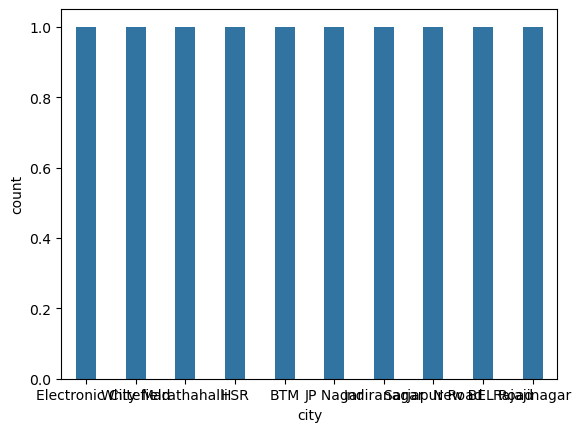

In [169]:
sns.countplot(s,gap=0.5)

__FINDING POPULAR CUISINES__

In [170]:
s=df['Cuisines'].value_counts

In [148]:
s

<bound method IndexOpsMixin.value_counts of 0       South Indian, North Indian, Chinese, Street Fo...
1                  Biryani, Andhra, North Indian, Seafood
2                                                 Biryani
3                              Pizza, Fast Food, Desserts
4         Burger, Fast Food, Biryani, Desserts, Beverages
                              ...                        
8918                                            Fast Food
8919                      Seafood, Mangalorean, Beverages
8920                                       Salad, Chinese
8921                                        Thai, Chinese
8922                                   Biryani, Fast Food
Name: Cuisines, Length: 8923, dtype: object>

In [ ]:
#CONVERTING FROM STRING TO FLOAT

In [149]:
df['Delivery Ratings'] = df['Delivery Ratings'].replace('-',np.nan).astype(float)

In [150]:
df['Dinner Ratings']=df['Dinner Ratings'].replace('-',np.nan).astype(float)

In [151]:
df['Delivery Ratings'] = df['Delivery Ratings'].fillna(0.0)
df['Dinner Ratings'] = df['Dinner Ratings'].fillna(0.0)
df['Overall Ratings'] = df[['Delivery Ratings','Dinner Ratings']].mean(axis=1)

In [152]:
df['Overall Ratings']

0       4.05
1       4.30
2       3.70
3       3.40
4       3.40
        ... 
8918    3.85
8919    4.10
8920    1.85
8921    3.65
8922    1.95
Name: Overall Ratings, Length: 8923, dtype: float64

In [ ]:
#SEPERATING THE MULTIPLE CUISINES

In [153]:
df = df.assign(Cuisines=df['Cuisines'].str.split(', ')).explode('Cuisines')

In [154]:
df

,Name,URL,Cuisines,Area,Timing,Full_Address,PhoneNumber,IsHomeDelivery,isTakeaway,isIndoorSeating,...,Dinner Ratings,Dinner Reviews,Delivery Ratings,Delivery Reviews,KnownFor,PopularDishes,PeopleKnownFor,AverageCost,city,Overall Ratings
0,Sri Udupi Park,https://www.zomato.com/bangalore/sri-udupi-par...,South Indian,"Indiranagar, Bangalore",7am – 11pm (Today),"273, Monalisa, 6th Main, 100 Feet Road, Indira...",+919945977774,1,1,1,...,4.0,462,4.1,16000,NaN,"Filtered Coffee, Sambhar, Pav Bhaji, Gobi Manc...","Economical, Prompt Service, Hygiene, Quality F...",450,Indiranagar,4.05
0,Sri Udupi Park,https://www.zomato.com/bangalore/sri-udupi-par...,North Indian,"Indiranagar, Bangalore",7am – 11pm (Today),"273, Monalisa, 6th Main, 100 Feet Road, Indira...",+919945977774,1,1,1,...,4.0,462,4.1,16000,NaN,"Filtered Coffee, Sambhar, Pav Bhaji, Gobi Manc...","Economical, Prompt Service, Hygiene, Quality F...",450,Indiranagar,4.05
0,Sri Udupi Park,https://www.zomato.com/bangalore/sri-udupi-par...,Chinese,"Indiranagar, Bangalore",7am – 11pm (Today),"273, Monalisa, 6th Main, 100 Feet Road, Indira...",+919945977774,1,1,1,...,4.0,462,4.1,16000,NaN,"Filtered Coffee, Sambhar, Pav Bhaji, Gobi Manc...","Economical, Prompt Service, Hygiene, Quality F...",450,Indiranagar,4.05
0,Sri Udupi Park,https://www.zomato.com/bangalore/sri-udupi-par...,Street Food,"Indiranagar, Bangalore",7am – 11pm (Today),"273, Monalisa, 6th Main, 100 Feet Road, Indira...",+919945977774,1,1,1,...,4.0,462,4.1,16000,NaN,"Filtered Coffee, Sambhar, Pav Bhaji, Gobi Manc...","Economical, Prompt Service, Hygiene, Quality F...",450,Indiranagar,4.05
0,Sri Udupi Park,https://www.zomato.com/bangalore/sri-udupi-par...,Biryani,"Indiranagar, Bangalore",7am – 11pm (Today),"273, Monalisa, 6th Main, 100 Feet Road, Indira...",+919945977774,1,1,1,...,4.0,462,4.1,16000,NaN,"Filtered Coffee, Sambhar, Pav Bhaji, Gobi Manc...","Economical, Prompt Service, Hygiene, Quality F...",450,Indiranagar,4.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8920,Bangkok Bowl,https://www.zomato.com/bangalore/bangkok-bowl-...,Chinese,"Kammanahalli, Bangalore","12noon – 3pm, 6:30pm – 10pm (Today)","403, 3A Cross, Mariayappa Road, Kammanahalli, ...",+919739999170,1,1,0,...,0.0,0,3.7,254,NaN,NaN,"Contactless Delivery, Portion, Great Portions,...",300,Kammanahalli,1.85
8921,Yuan Restaurant,https://www.zomato.com/bangalore/yuan-restaura...,Thai,"HBR Layout, Bangalore",Opens at 7pm,"2&3, Renu Arcade, 1st Stage, 2nd Block, 80 Fee...",+919901047070,1,1,1,...,3.8,188,3.5,3169,NaN,NaN,"Calm, Prompt Service, Portions, Spicy, Delicio...",400,HBR Layout,3.65
8921,Yuan Restaurant,https://www.zomato.com/bangalore/yuan-restaura...,Chinese,"HBR Layout, Bangalore",Opens at 7pm,"2&3, Renu Arcade, 1st Stage, 2nd Block, 80 Fee...",+919901047070,1,1,1,...,3.8,188,3.5,3169,NaN,NaN,"Calm, Prompt Service, Portions, Spicy, Delicio...",400,HBR Layout,3.65
8922,Amma's Biryani & Rice,https://www.zomato.com/bangalore/ammas-biryani...,Biryani,"Kammanahalli, Bangalore",11:30am – 11:30pm (Today),"21, Ground Floor, Praise The Lord Mansion, Neh...",+917349446837,1,1,1,...,3.9,6,0.0,18,NaN,NaN,NaN,300,Kammanahalli,1.95


In [155]:
t=df.groupby('Cuisines')['Overall Ratings'].mean().sort_values(ascending=False)

In [156]:
t.head(10)

Cuisines
Nepalese       4.300
Malaysian      4.200
African        4.150
Assamese       4.150
Cantonese      4.050
Singaporean    4.040
Iranian        3.950
British        3.925
Konkan         3.875
Parsi          3.875
Name: Overall Ratings, dtype: float64

Text(0, 0.5, 'Cuisine')

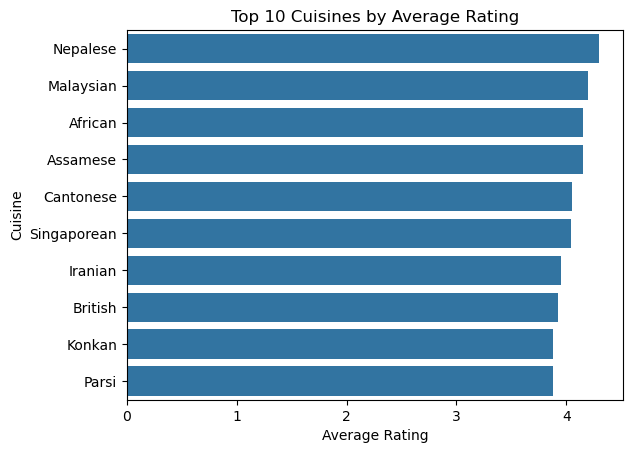

In [179]:
top_cuisines = df.groupby('Cuisines')['Overall Ratings'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top_cuisines.values, y=top_cuisines.index)
plt.title("Top 10 Cuisines by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")

__RATINGS AFFECT COST__

In [158]:
t=df.groupby('Overall Ratings')['AverageCost'].mean().sort_values(ascending=False)

In [159]:
t=pd.DataFrame(t)

<Axes: xlabel='Overall Ratings', ylabel='AverageCost'>

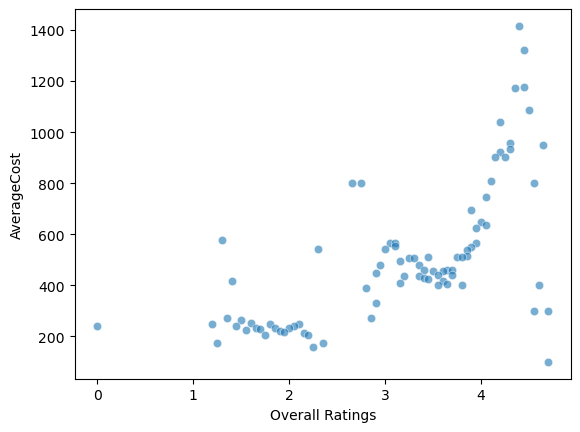

In [160]:
sns.scatterplot(data=t, x='Overall Ratings', y='AverageCost', alpha=0.6)


Text(0.5, 1.0, 'Average Cost Distribution Across Ratings')

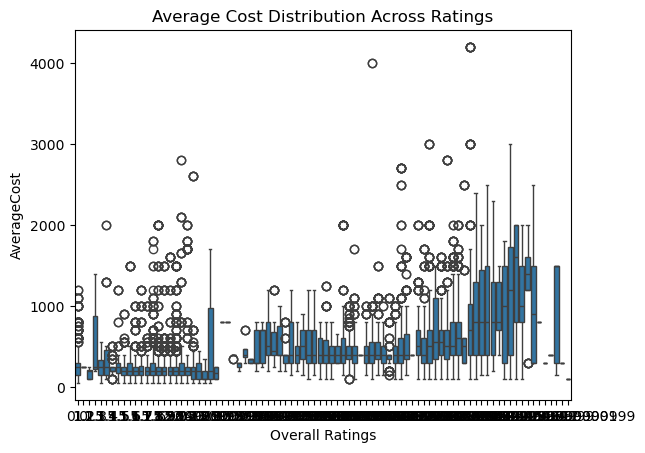

In [180]:
sns.boxplot(x='Overall Ratings', y='AverageCost', data=df)
plt.title("Average Cost Distribution Across Ratings")

In [162]:
#SHOWS THAT FEW RESTRAUNTS ARE VERY COSTLY THAN THE AVG COST

In [163]:
#SCATTER PLOT SHOWS THAT GENERALLY HIGHER RATING = HIGHER PRICES

__FEW VISUALIZATIONS__

In [ ]:
#Distribution of Restaurant Ratings

Text(0, 0.5, 'Count')

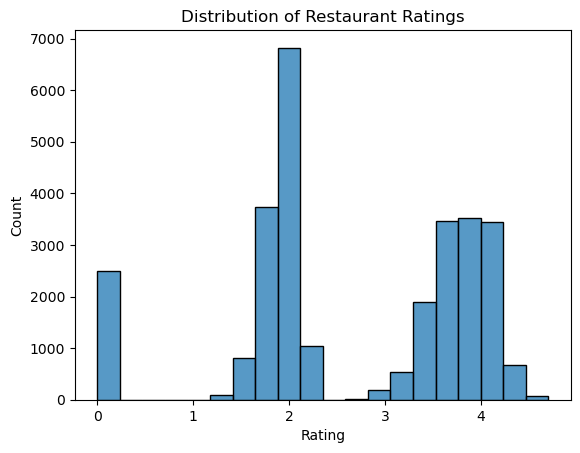

In [171]:
sns.histplot(df['Overall Ratings'], bins=20)
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

In [ ]:
#This histogram shows the distribution of restaurant ratings in the dataset.
#Most restaurants have ratings between 3.0 and 4.5 -indicating that the majority of restaurants are moderately to highly rated.

In [172]:
#Cost Distribution of Restaurants

Text(0, 0.5, 'Frequency')

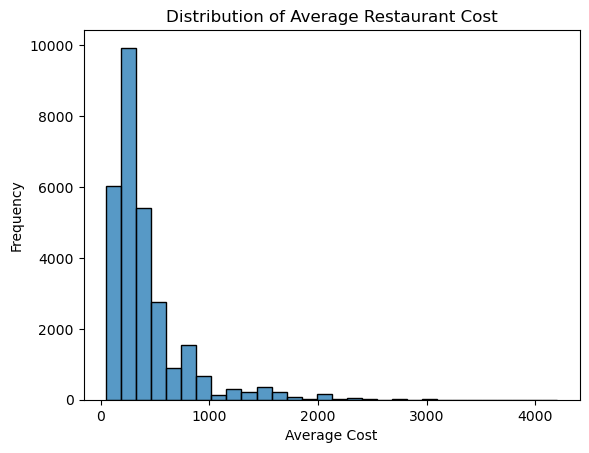

In [173]:
sns.histplot(df['AverageCost'], bins=30)
plt.title("Distribution of Average Restaurant Cost")
plt.xlabel("Average Cost")
plt.ylabel("Frequency")

In [176]:
#Cost Distribution by Rating (Boxplot)